# 05 Spatial analysis

Aimag-level drought sensitivity of annual livestock mortality.

| Output | Manuscript |
| --- | --- |
| `figures/figure_09_drought_sensitivity_map.pdf` | Figure 9 |
| printed tables | Tables S5, S6 |

Reads only `data/processed/`. No raw file is opened.

In [45]:
import sys, os
from pathlib import Path

REPO = "mongolia-dzud-drought"
IN_COLAB = "google.colab" in sys.modules or Path("/content").exists()

if IN_COLAB and not Path(REPO).exists() and Path.cwd().name != REPO:
    !git clone -q https://github.com/nominkhurelchuluun/{REPO}.git /content/{REPO}
    os.chdir(f"/content/{REPO}")
elif Path.cwd().name == "notebooks":
    os.chdir("..")

sys.path.insert(0, str(Path.cwd()))

!pip install -q mapclassify

import numpy as np
import pandas as pd

from src import data_loading as dl
dl.describe_paths()

DATA_DIR      /content/mongolia-dzud-drought/data
RAW_DIR       /content/mongolia-dzud-drought/data/raw
PROCESSED_DIR /content/mongolia-dzud-drought/data/processed
FIG_DIR       /content/mongolia-dzud-drought/figures


In [46]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from matplotlib.cm import ScalarMappable
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.ticker import FuncFormatter
from scipy import stats

from src import data_loading as dl

dl.set_plot_style()
dl.describe_paths()

panel = dl.load_mortality_panel()
aimags = dl.load_aimag_boundaries()
spei_trends = dl.load_spei("aimag_trends")

print(f"panel: {len(panel)} rows, {panel['Aimag'].nunique()} aimags")

DATA_DIR      /content/mongolia-dzud-drought/data
RAW_DIR       /content/mongolia-dzud-drought/data/raw
PROCESSED_DIR /content/mongolia-dzud-drought/data/processed
FIG_DIR       /content/mongolia-dzud-drought/figures
panel: 693 rows, 21 aimags


## Table S5. Aimag-level drought sensitivity

For each aimag, annual mortality in year t is regressed on mean June-August SPEI-3 in
year t-1. Beta is reported as the negative of the fitted slope, so positive values
mean higher mortality after drier summers.

`SENSITIVITY_COL` selects the mortality measure. `All` is the unweighted mean of the
five species rates and reproduces the submitted map. `All_SFU` is the Equation (2)
rate. Both rankings are printed.

In [47]:
SENSITIVITY_COL = "All"


def aimag_sensitivity(column):
    rows = []
    for aimag, group in panel.groupby("Aimag"):
        subset = group.dropna(subset=["SPEI_PrevSummer", column])
        if len(subset) < 5:
            continue
        fit = stats.linregress(subset["SPEI_PrevSummer"], subset[column] * 100)
        rows.append({"Aimag": aimag, "Beta": -fit.slope, "r": fit.rvalue,
                     "p_value": fit.pvalue, "n": len(subset)})
    return (pd.DataFrame(rows).sort_values("Beta", ascending=False)
            .reset_index(drop=True))


sensitivity = aimag_sensitivity(SENSITIVITY_COL)
sensitivity_sfu = aimag_sensitivity("All_SFU")

print(f"Table S5. Drought sensitivity using {SENSITIVITY_COL}")
print(sensitivity.round(3).to_string(index=False))

comparison = (sensitivity[["Aimag", "Beta"]]
              .rename(columns={"Beta": "Beta_All"})
              .merge(sensitivity_sfu[["Aimag", "Beta"]]
                     .rename(columns={"Beta": "Beta_All_SFU"}), on="Aimag"))
comparison["Rank_All"] = comparison["Beta_All"].rank(ascending=False).astype(int)
comparison["Rank_All_SFU"] = comparison["Beta_All_SFU"].rank(ascending=False).astype(int)

print("\nRanking under each mortality measure")
print(comparison.sort_values("Rank_All").round(3).to_string(index=False))

Table S5. Drought sensitivity using All
       Aimag   Beta      r  p_value  n
  Sukhbaatar  3.299 -0.376    0.031 33
    Umnugovi  3.093 -0.352    0.045 33
Bayankhongor  3.023 -0.326    0.064 33
  Govi-Altai  2.989 -0.302    0.088 33
   Dornogovi  2.821 -0.352    0.045 33
 Uvurkhangai  2.796 -0.287    0.106 33
    Dundgovi  2.617 -0.264    0.137 33
  Govisumber  1.955 -0.190    0.289 33
 Bayan-Ulgii  1.787 -0.388    0.026 33
     Zavkhan  1.762 -0.214    0.232 33
         Uvs  1.728 -0.279    0.116 33
       Khovd  1.406 -0.302    0.088 33
   Arkhangai  1.271 -0.181    0.315 33
     Khentii  1.263 -0.166    0.355 33
    Khuvsgul  1.043 -0.175    0.330 33
         Tuv  1.019 -0.150    0.404 33
      Orkhon  0.537 -0.177    0.326 33
      Bulgan  0.377 -0.053    0.771 33
      Dornod  0.115 -0.021    0.906 33
     Selenge -0.105  0.037    0.840 33
 Darkhan-Uul -0.191  0.069    0.702 33

Ranking under each mortality measure
       Aimag  Beta_All  Beta_All_SFU  Rank_All  Rank_All_SFU
  S

## Figure 9. Drought sensitivity map

saved /content/mongolia-dzud-drought/figures/figure_09_drought_sensitivity_map.pdf  (170 x 109 mm at print size)


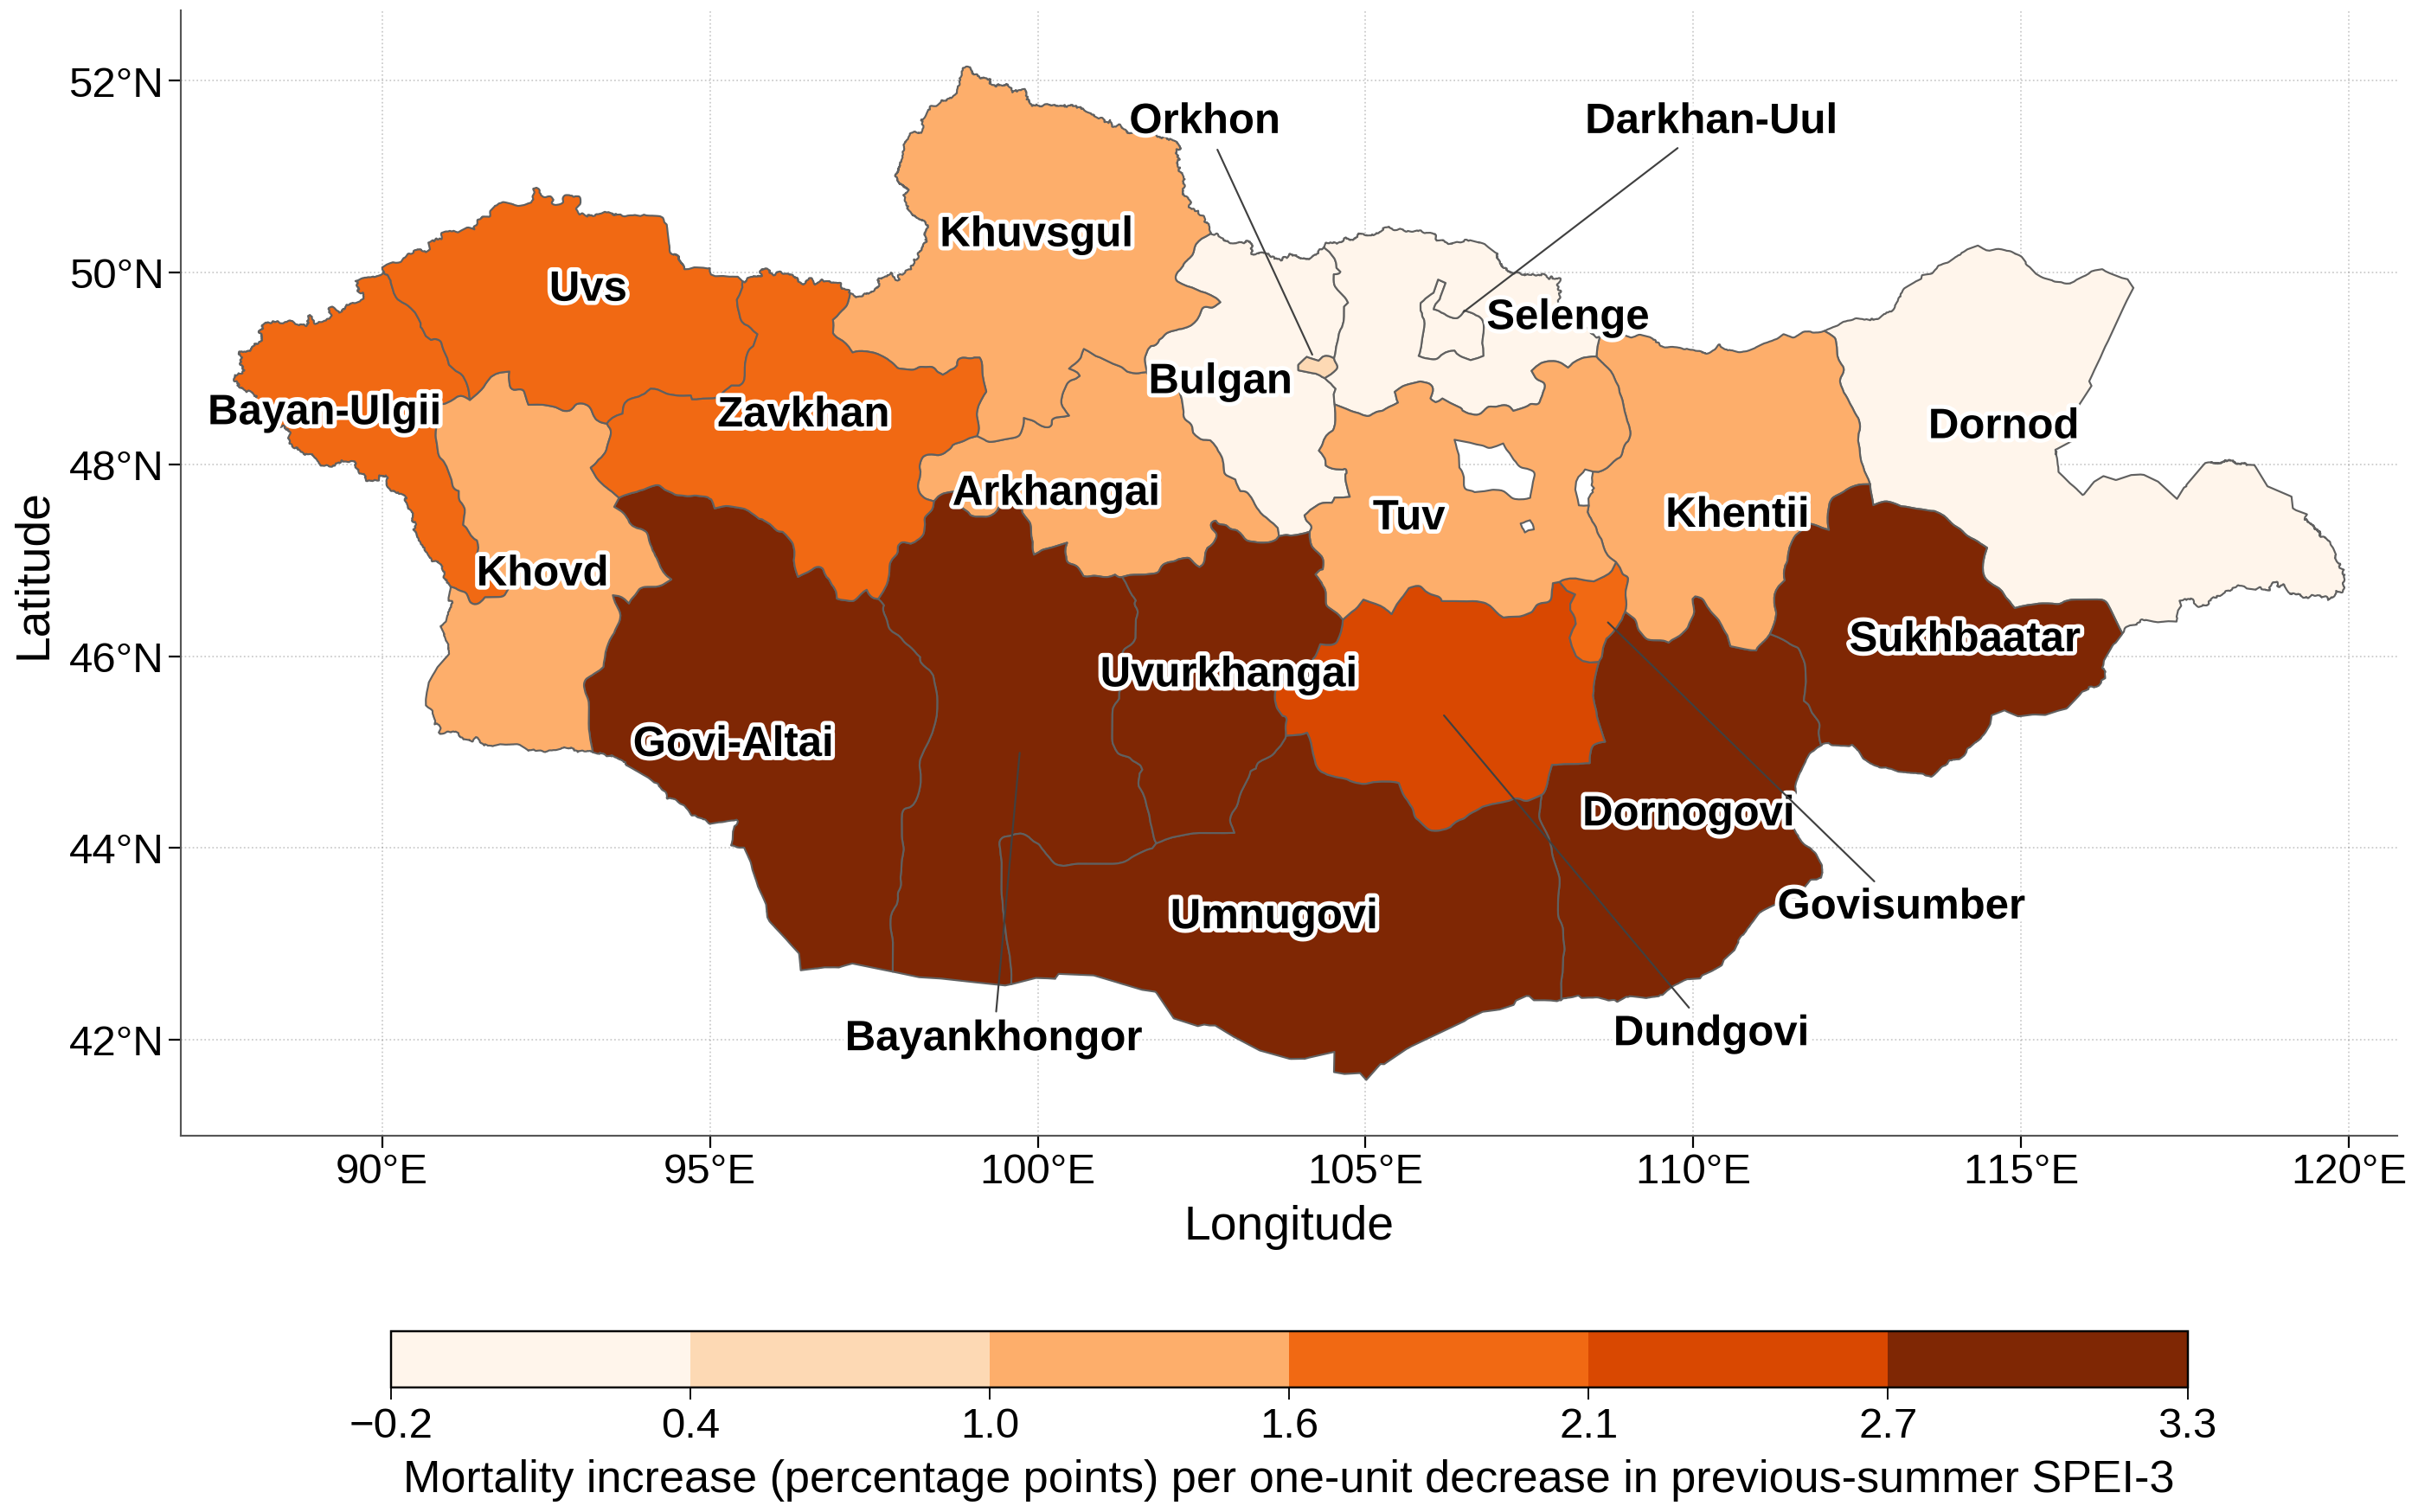

In [48]:
MAP_SCALE = 3.4
LEADER_SCALE = 1.0

MAP_COLORS = ["#FFF5EB", "#FDD9B4", "#FDAE6B", "#F16913", "#D94801", "#7F2704"]

LABEL_OFFSETS = {
    "Bayan-Ulgii": (-24, 16),
    "Khovd": (-16, -8),
    "Uvs": (10, 10),
    "Zavkhan": (6, 12),
    "Govi-Altai": (-18, -12),
    "Arkhangai": (-10, -20),
    "Uvurkhangai": (16, 4),
    "Khuvsgul": (-12, 12),
    "Tuv": (2, -20),
    "Umnugovi": (-4, -8),
    "Dornogovi": (14, -10),
    "Sukhbaatar": (12, -6),
    "Khentii": (12, -16),
    "Dornod": (24, 6),
    "Bulgan": (-18, 2),
    "Selenge": (22, 2)}


mapped = aimags.merge(sensitivity, on="Aimag", how="left")
if mapped["Beta"].isna().any():
    missing = mapped.loc[mapped["Beta"].isna(), "Aimag"].tolist()
    print(f"Aimags without a sensitivity estimate: {missing}")

values = mapped["Beta"].dropna().to_numpy()
boundaries = np.round(np.linspace(values.min(), values.max(),
                                  len(MAP_COLORS) + 1), 1)
cmap = ListedColormap(MAP_COLORS)
cmap.set_bad("#DDDDDD")
norm = BoundaryNorm(boundaries, ncolors=cmap.N, clip=True)

with mpl.rc_context({"font.size": 8 * MAP_SCALE,
                     "axes.labelsize": 9 * MAP_SCALE,
                     "xtick.labelsize": 8 * MAP_SCALE,
                     "ytick.labelsize": 8 * MAP_SCALE,
                     "axes.linewidth": 0.4 * MAP_SCALE,
                     "pdf.fonttype": 42, "ps.fonttype": 42}):

    fig, ax = plt.subplots(
        figsize=(dl.AGU_MAX_WIDTH_IN * MAP_SCALE, 4.3 * MAP_SCALE),
        facecolor="white")

    mapped.plot(column="Beta", cmap=cmap, norm=norm, linewidth=0.35 * MAP_SCALE,
                edgecolor="#606060", ax=ax, legend=False,
                missing_kwds={"color": "#DDDDDD", "hatch": "///",
                              "edgecolor": "#808080"}, zorder=2)

    dl.draw_aimag_labels(ax, mapped, fontsize=8 * MAP_SCALE, scale=MAP_SCALE,
                         offsets=LABEL_OFFSETS, leader_scale=LEADER_SCALE)

    min_lon, min_lat, max_lon, max_lat = mapped.total_bounds
    dl.expand_limits_for_labels(ax, mapped, leader_scale=LEADER_SCALE)
    ax.set_xticks(np.arange(90, 121, 5))
    ax.set_yticks(np.arange(42, 53, 2))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{v:.0f}\u00b0E"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{v:.0f}\u00b0N"))
    ax.set_xlabel("Longitude", fontsize=9 * MAP_SCALE, labelpad=8)
    ax.set_ylabel("Latitude", fontsize=9 * MAP_SCALE, labelpad=8)
    ax.tick_params(axis="both", which="major", labelsize=8 * MAP_SCALE,
                   direction="out", length=2.2 * MAP_SCALE, width=0.36 * MAP_SCALE)
    ax.grid(color="#777777", linestyle=":", linewidth=0.28 * MAP_SCALE, alpha=0.40)
    ax.set_axisbelow(True)
    ax.set_aspect(1 / np.cos(np.deg2rad((min_lat + max_lat) / 2)))

    for spine in ax.spines.values():
        spine.set_color("#555555")
        spine.set_linewidth(0.35 * MAP_SCALE)

    scalar = ScalarMappable(norm=norm, cmap=cmap)
    scalar.set_array([])
    colorbar = fig.colorbar(scalar, ax=ax, orientation="horizontal",
                            boundaries=boundaries, ticks=boundaries,
                            spacing="uniform", fraction=0.055, pad=0.14,
                            shrink=0.78, aspect=32)
    colorbar.set_label("Mortality increase (percentage points) per one-unit "
                       "decrease in previous-summer SPEI-3",
                       fontsize=8.5 * MAP_SCALE, labelpad=8)
    colorbar.ax.tick_params(axis="x", which="major", labelsize=8 * MAP_SCALE,
                            length=2.2 * MAP_SCALE, width=0.3 * MAP_SCALE, pad=5)

    fig.subplots_adjust(left=0.08, right=0.98, top=0.97, bottom=0.12)

dl.save_figure(fig, "figure_09_drought_sensitivity_map", scale=MAP_SCALE)
plt.show()

## Table S6. Aimag drying rates, 1950-2024

The trend table produced in notebook 01. The 1992-2024 period is printed alongside it
because section 3.2 of the manuscript quotes that period while Table S6 reports
1950-2024.

In [49]:
table_s6 = spei_trends[
    spei_trends["Period"].eq(f"{dl.SPEI_START}-{dl.SPEI_END}")].copy()
print(f"Table S6. Mean June-August SPEI-3 trends, {dl.SPEI_START}-{dl.SPEI_END}")
print(table_s6[["Aimag", "Drying_rate_per_decade", "SPEI_slope_per_decade",
                "r", "p_value", "N_years"]].round(6).to_string(index=False))

trends_1992 = spei_trends[
    spei_trends["Period"].eq(f"{dl.MORT_START}-{dl.MORT_END}")].copy()
print(f"\nSame quantity over {dl.MORT_START}-{dl.MORT_END}")
print(trends_1992[["Aimag", "Drying_rate_per_decade", "r", "p_value", "N_years"]]
      .round(4).to_string(index=False))

Table S6. Mean June-August SPEI-3 trends, 1950-2024
       Aimag  Drying_rate_per_decade  SPEI_slope_per_decade         r  p_value  N_years
   Arkhangai                0.252910              -0.252910 -0.649669 0.000000       75
  Govisumber                0.244167              -0.244167 -0.559228 0.000000       75
         Tuv                0.229439              -0.229439 -0.556993 0.000000       75
    Dundgovi                0.221698              -0.221698 -0.586559 0.000000       75
 Uvurkhangai                0.208859              -0.208859 -0.568415 0.000000       75
      Orkhon                0.192560              -0.192560 -0.446034 0.000061       75
      Bulgan                0.190962              -0.190962 -0.492377 0.000007       75
     Khentii                0.184638              -0.184638 -0.477638 0.000015       75
   Dornogovi                0.182381              -0.182381 -0.512409 0.000003       75
    Umnugovi                0.173463              -0.173463 -0.49976

## Exposure against sensitivity

The manuscript argues that the fastest-drying aimags are not necessarily the most
sensitive. This cell produces the ranked comparison behind that claim, so the three
lists quoted in section 3.2, the Discussion and lines 443-445 can be reconciled
against one source.

In [50]:
exposure = (trends_1992[["Aimag", "Drying_rate_per_decade", "p_value"]]
            .rename(columns={"p_value": "Trend_p"}))

combined = (sensitivity[["Aimag", "Beta", "r", "p_value"]]
            .rename(columns={"p_value": "Sensitivity_p"})
            .merge(exposure, on="Aimag", how="outer"))
combined["Sensitivity_rank"] = combined["Beta"].rank(ascending=False)
combined["Drying_rank"] = combined["Drying_rate_per_decade"].rank(ascending=False)
combined["Rank_difference"] = combined["Drying_rank"] - combined["Sensitivity_rank"]

print("Ranked by drought sensitivity")
print(combined.sort_values("Sensitivity_rank")
      [["Aimag", "Beta", "Sensitivity_p", "Sensitivity_rank",
        "Drying_rate_per_decade", "Trend_p", "Drying_rank", "Rank_difference"]]
      .round(3).to_string(index=False))

top_sensitivity = set(combined.nsmallest(7, "Sensitivity_rank")["Aimag"])
top_drying = set(combined.nsmallest(8, "Drying_rank")["Aimag"])

print(f"\nSeven strongest sensitivities: {sorted(top_sensitivity)}")
print(f"Eight fastest-drying aimags ({dl.MORT_START}-{dl.MORT_END}): "
      f"{sorted(top_drying)}")
print(f"In both lists: {sorted(top_sensitivity & top_drying)}")
print(f"Strong sensitivity but not fast drying: "
      f"{sorted(top_sensitivity - top_drying)}")
print(f"Fast drying but not strong sensitivity: "
      f"{sorted(top_drying - top_sensitivity)}")

correlation = combined.dropna(subset=["Beta", "Drying_rate_per_decade"])
fit = stats.linregress(correlation["Drying_rate_per_decade"], correlation["Beta"])
print(f"\nSensitivity against drying rate: r = {fit.rvalue:.3f}, "
      f"p = {fit.pvalue:.3f}, n = {len(correlation)}")

Ranked by drought sensitivity
       Aimag   Beta  Sensitivity_p  Sensitivity_rank  Drying_rate_per_decade  Trend_p  Drying_rank  Rank_difference
  Sukhbaatar  3.299          0.031               1.0                   0.214    0.132         14.0             13.0
    Umnugovi  3.093          0.045               2.0                   0.482    0.000          5.0              3.0
Bayankhongor  3.023          0.064               3.0                   0.448    0.003          8.0              5.0
  Govi-Altai  2.989          0.088               4.0                   0.524    0.001          4.0              0.0
   Dornogovi  2.821          0.045               5.0                   0.363    0.004         11.0              6.0
 Uvurkhangai  2.796          0.106               6.0                   0.451    0.002          6.0              0.0
    Dundgovi  2.617          0.137               7.0                   0.449    0.001          7.0              0.0
  Govisumber  1.955          0.289        